In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



#Initial extraction of data and refining for the PGCB Report
Firstly, I extracted the data which was necessary, from the main PGCB report, mainly considering the data, the primarily important data seems to be the demand, supply and load shedding, since the rest of the parameters are not in the least affecting the demand for the next hour, since they are explaining where the energy came from, which is not related to the consumption end of the problem.

In [ ]:
df_pgcb = pd.read_excel('PGCB_date_power_demand.xlsx')
df_pgcb['datetime'] = pd.to_datetime(df_pgcb['datetime'], errors='coerce')
df_pgcb = df_pgcb.sort_values('datetime')
df_pgcb = df_pgcb.drop_duplicates()
df_pgcb = df_pgcb.drop_duplicates(subset = ['datetime'], keep='first')
df_pgcb = df_pgcb.set_index('datetime')

#Here we will be taking the average for the uneven data points such as 18:00 and 18:30
df_target = df_pgcb[['demand_mw', 'generation_mw', 'load_shedding']].resample('h').mean()

#Check for inconsistent time samples
missing_hours = df_target['demand_mw'].isnull().sum()
print(f"Missing hourly entries listed: {missing_hours}")

print(df_target.head())


Missing hourly entries listed: 1051
                     demand_mw  generation_mw  load_shedding
datetime                                                    
2015-04-19 00:00:00     4821.0         4821.0            0.0
2015-04-19 01:00:00     3612.0         3612.0            0.0
2015-04-19 02:00:00     3727.0         3727.0            0.0
2015-04-19 03:00:00     3632.0         3632.0            0.0
2015-04-19 04:00:00     3641.0         3641.0            0.0


Now we will be handling unavailable data, the spikes and extremes mentioned in the PS document. To handle inconsistent data, like missing value for demand/supply for 2pm, when 1pm and 3 pm data is available. The possible options were either forward filling, or linear interpolation, out of which, linear interpolation is more reasonable since it helps reduce spikes in data and also ensures a practical logic of consistently increasing demand, rather than spiking of supply  suddenly

For handling the spikes of data, I needed to either use a median or mean, but since a single global mean is not an accurate measure for the various seasonal variations, it'll fail to account for the minute complexities. So we'll create a 24 hour window, to check whether any data point is exceptionally different from the median of it's surrounding's data.

In [ ]:
df_target = df_target.asfreq('H')
window_size = 24
rolling_mean = df_target['demand_mw'].rolling(window=window_size, center=True, min_periods=1).mean()
rolling_std = df_target['demand_mw'].rolling(window=window_size, center=True, min_periods=1).std()
z_scores = np.abs(df_target['demand_mw']-rolling_mean)/rolling_std
threshold = 3.5
anomalies_mask = z_scores > threshold
print(f"Detected {anomalies_mask.sum()} severe anamolies (spikes and crashes)")
df_target.loc[anomalies_mask, 'demand_mw'] = np.nan

df_target['demand_mw'] = df_target['demand_mw'].interpolate(method='linear')
df_target['generation_mw'] = df_target['generation_mw'].interpolate(method='linear')
#It's safe to assume zero load shedding where unavailabe since the data clearly shows that there's barely a few rows where the load shedding is non zero, where provided.
df_target['load_shedding']= df_target['load_shedding'].fillna(0)

print(f"Missing values remaining: {df_target['demand_mw'].isnull().sum()}")
print(f"Maximum Demand of the data is now: {df_target['demand_mw'].max()} MW")



Detected 48 severe anamolies (spikes and crashes)
Missing values remaining: 0
Maximum Demand of the data is now: 17200.0 MW


/tmp/ipykernel_6098/3062810498.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_target = df_target.asfreq('H')


Now we integrate the weather report and World Bank report, including the cleaning and refining, simlar to how it was done previously.

In [ ]:
df_weather = pd.read_excel('weather_data.xlsx', skiprows = 3)
df_weather['time'] = pd.to_datetime(df_weather['time'], errors='coerce')
df_weather = df_weather.dropna(subset = ['time']).set_index('time').sort_index()
weather_cols = ['temperature_2m (°C)', 'relative_humidity_2m (%)']
df_weather = df_weather[weather_cols].resample('h').mean().interpolate(method='linear')

df_master = df_target.merge(df_weather, left_index = True, right_index=True, how='left')

In [ ]:
df_econ = pd.read_csv('economic_full_1.csv')
indicators = ['GDP (constant 2015 US$)', 'Population, total']
df_econ_filtered = df_econ[df_econ['Indicator Name'].isin(indicators)]
df_econ_filtered = df_econ_filtered.drop(columns = ['Country Name', 'Indicator Code'])

df_econ_melted = pd.melt(
    df_econ_filtered,
    id_vars = ['Indicator Name'],
    var_name = 'Year',
    value_name = 'Value'
)

df_econ_melted['Year'] = pd.to_numeric(df_econ_melted['Year'], errors = 'coerce')
ef_econ_melted = df_econ_melted.dropna(subset = ['Year'])
df_macro = df_econ_melted.pivot(index = 'Year', columns = 'Indicator Name', values = 'Value').reset_index()

df_master['Year'] = df_master.index.year

master_index = df_master.index
df_master = df_master.merge(df_macro, on = 'Year', how = 'left')
df_master.index = master_index

df_master['GDP (constant 2015 US$)'] = df_master['GDP (constant 2015 US$)'].ffill().bfill()
df_master['Population, total'] = df_master['Population, total'].ffill().bfill()

print(df_master.info())
print("We have the timeline of all the variables combined")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 89101 entries, 2015-04-19 00:00:00 to 2025-06-17 12:00:00
Freq: h
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   demand_mw                 89101 non-null  float64
 1   generation_mw             89101 non-null  float64
 2   load_shedding             89101 non-null  float64
 3   temperature_2m (°C)       89101 non-null  float64
 4   relative_humidity_2m (%)  89101 non-null  float64
 5   Year                      89101 non-null  int32  
 6   GDP (constant 2015 US$)   89101 non-null  float64
 7   Population, total         89101 non-null  float64
dtypes: float64(7), int32(1)
memory usage: 5.8 MB
None
We have the timeline of all the variables combined


#Feature Engineering
Now, with the necessary parameters extracted out of the three files, let's move on to handling the addition of new parameters such that we take into account the effect of past demands, thus setting up the demands from the past timelines, which would generate the model's sense of time relation, without ever actually using any LSTM or ARIMA, while also accounting for lags in supply.

In [ ]:
df_master['hour'] = df_master.index.hour
df_master['day_of_week'] = df_master.index.day_of_week
df_master['month'] = df_master.index.month
df_master['day_of_year'] = df_master.index.day_of_year

# Here, rather than the conventional weekend on saturday and sunday, we check the dataset and it turns out that the average power consumption by day is the lowest on Friday and saturday, and the fact that the organisation PGCB works in Bagladesh, where weekends are generally taken on Friday and Saturday, we make the appropriate changes in our use.
df_master['is_weekend'] = df_master['day_of_week'].apply(lambda x: 1 if x in [4, 5] else 0)

df_master['demand_over_last_hour'] = df_master['demand_mw'].shift(1)
df_master['demand_over_last_2_hours'] = df_master['demand_mw'].shift(2)
df_master['demand_over_last_24_hours'] = df_master['demand_mw'].shift(24)
df_master['demand_over_last_week'] = df_master['demand_mw'].shift(168)

df_master['shedding_lag_over_1_hour'] = df_master['load_shedding'].shift(1)
df_master['shedding_lag_over_last_24_hours'] = df_master['load_shedding'].shift(24)

df_master['rolling_mean_24h'] = df_master['demand_mw'].rolling(window=24).mean()
df_master['rolling_mean_168h'] = df_master['demand_mw'].rolling(window=168).mean()

# Now we shift the time index make a target prediction column.
df_master['target_mw'] = df_master['demand_mw'].shift(-1)

df_master = df_master.dropna()

print(f"Final dataset ready for moulding: {df_master.shape}")


Final dataset ready for moulding: (88932, 22)


# Final Model Training
Now, we start the final phase of the task, the training. Now, since a basic linear regression model requires scaling and additional work, we use the Random Forest model and on top of that, we use the CatBoost, and finally ensemble the results, thus getting the best of both the models. Basically, we use the two models to check for any errors in our outcomes, since large variations would just mean either one is simply overfitting or some other malfunction is happening. Thus we use Random Forest Regressor and CatBoost Regressor, and in case both models are pretty close, we also use ensembling to see if that help our case.

#Random_Forest Regressor

Training Data: 2015-04-26 00:00:00 to 2024-06-17 11:00:00
Testing Data: 2024-06-17 12:00:00 to 2025-06-17 11:00:00
MAPE: 0.01955356463194341
RMSE: 355.1535405485994


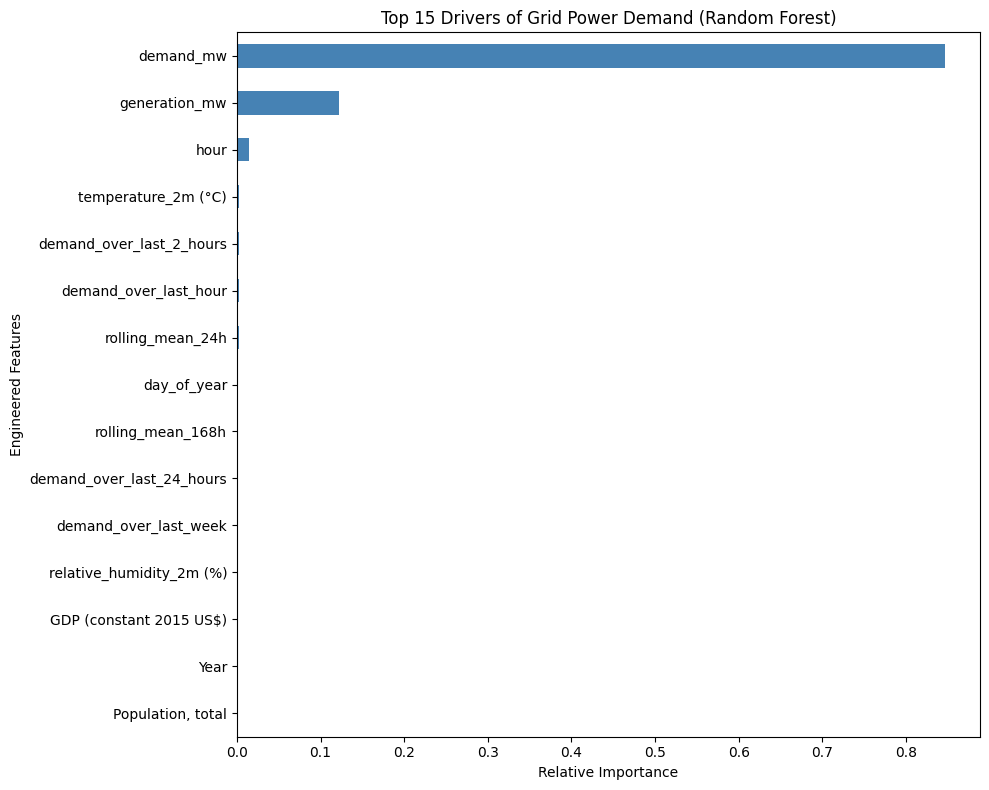

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

X = df_master.drop(columns = ['target_mw'])
y = df_master['target_mw']

test_size_hours = 24*365

X_train = X.iloc[:-test_size_hours]
y_train = y.iloc[:-test_size_hours]

X_test = X.iloc[-test_size_hours:]
y_test = y.iloc[-test_size_hours:]

print(f"Training Data: {X_train.index.min()} to {X_train.index.max()}")
print(f"Testing Data: {X_test.index.min()} to {X_test.index.max()}")

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
#mention the use of error scales
importances = pd.Series(rf_model.feature_importances_, index=X_test.columns).sort_values(ascending=True)
print(f"MAPE: {mape}")
print(f"RMSE: {rmse}")

# Here I used the obtained data to plot the depenedencies of the model's predictions on the existing parameters
plt.figure(figsize=(10, 8))
importances.tail(15).plot(kind='barh', color='steelblue')
plt.title("Top 15 Drivers of Grid Power Demand (Random Forest)")
plt.xlabel("Relative Importance")
plt.ylabel("Engineered Features")
plt.tight_layout()
plt.show()


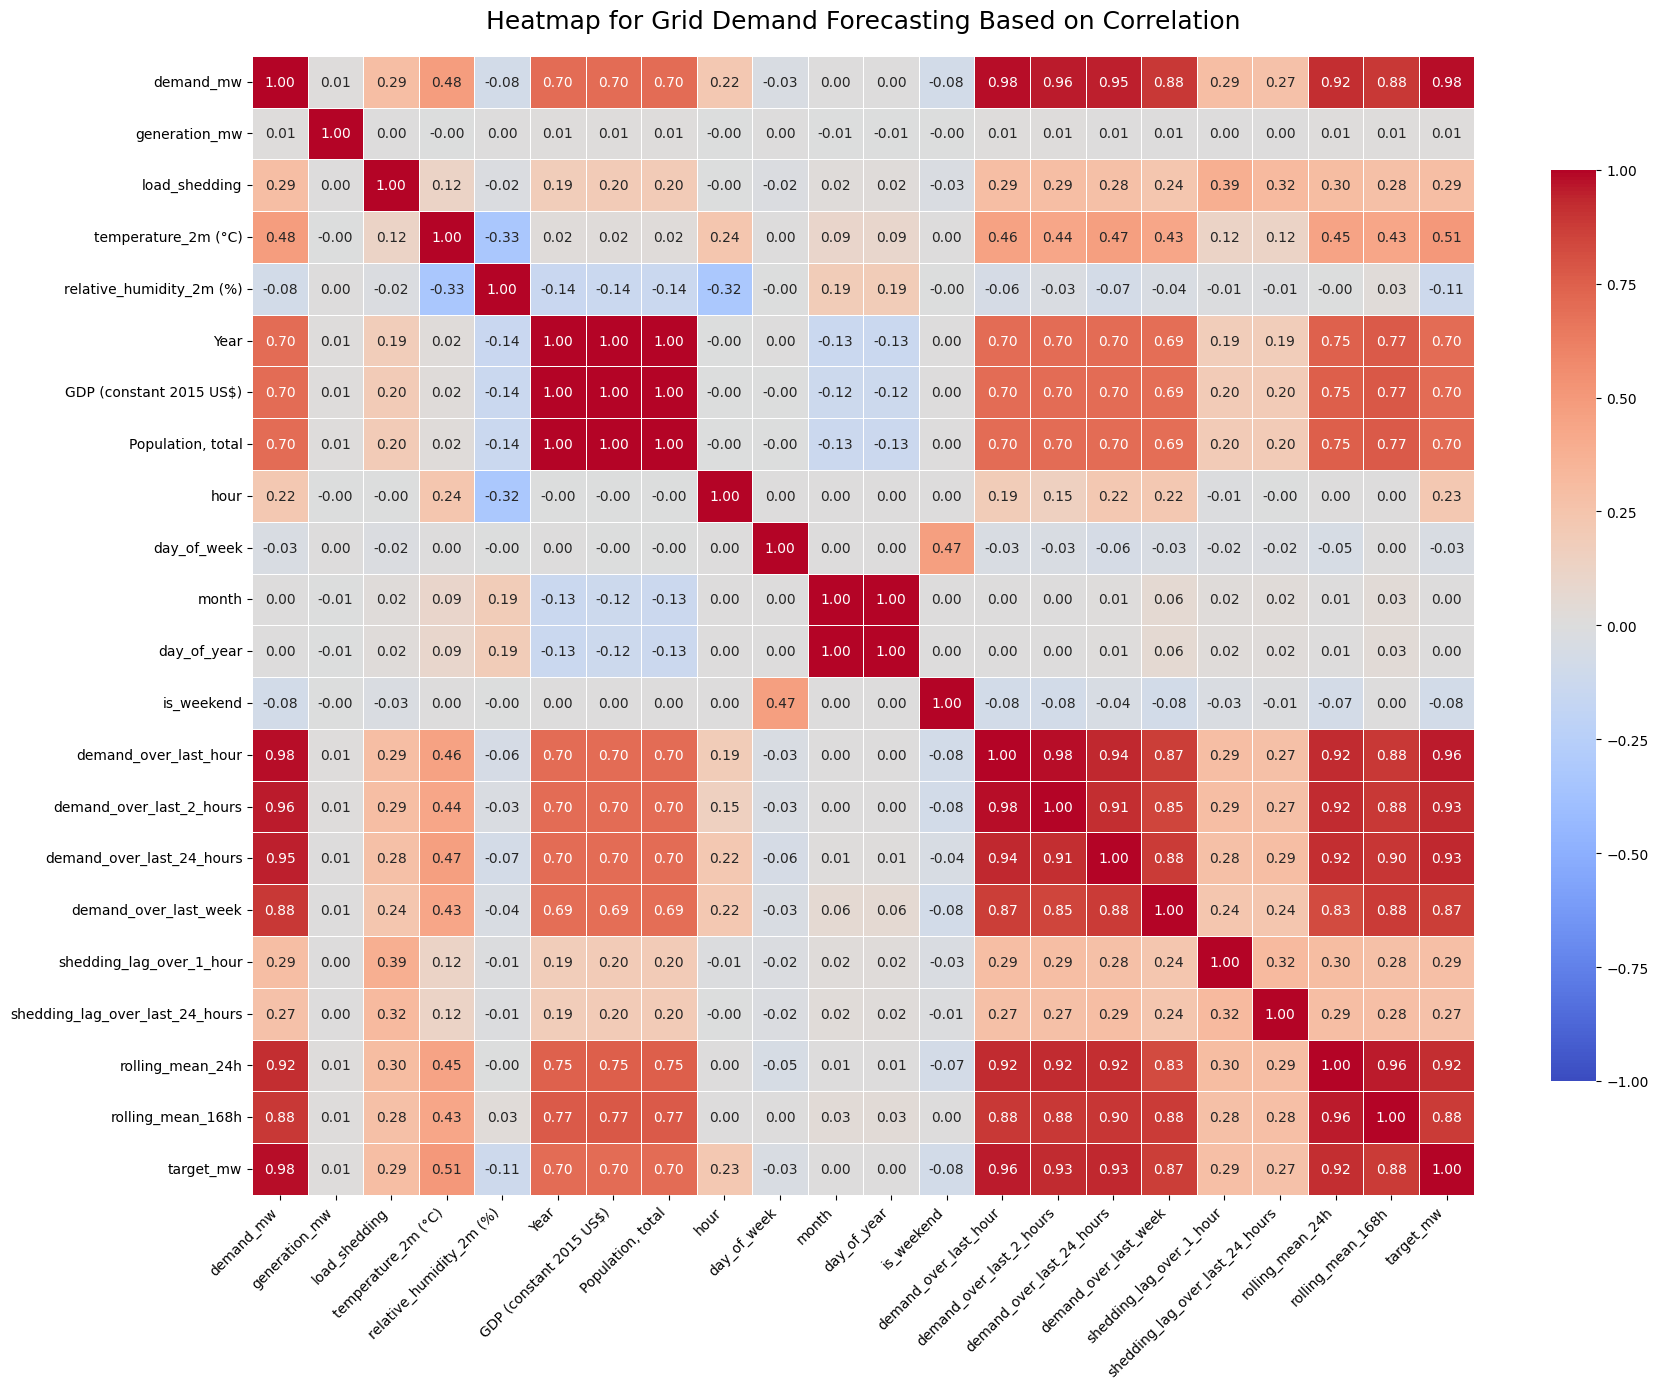

In [ ]:
corr_matrix = df_master.corr()
plt.figure(figsize=(18, 14))

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=0.5,
            cbar_kws={"shrink": .8}
)

plt.title("Heatmap for Grid Demand Forecasting Based on Correlation", fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#CatBoost
Now we try the CatBoost model

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error

cb_model = CatBoostRegressor(
    iterations = 500,
    learning_rate = 0.05,
    depth = 8,
    loss_function = 'RMSE',
    verbose = 0,
    random_seed = 42
)

cb_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)

cb_pred = cb_model.predict(X_test)

cb_mape = mean_absolute_percentage_error(y_test, cb_pred)
cb_rmse = np.sqrt(mean_squared_error(y_test, cb_pred))
print(f"MAPE: {cb_mape}")
print(f"RMSE: {cb_rmse}")




MAPE: 0.016275745630941515
RMSE: 257.5797106233186


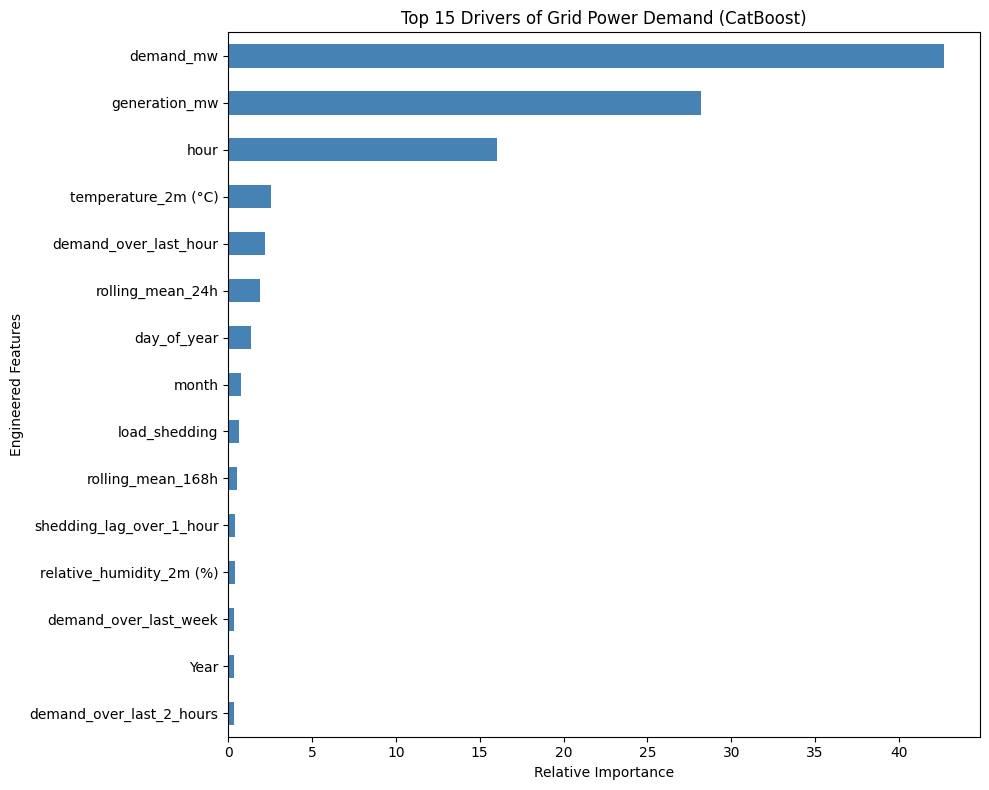

In [ ]:
cb_importances = cb_model.get_feature_importance()
cb_importance_series = pd.Series(cb_importances, index=X_test.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
cb_importance_series.tail(15).plot(kind='barh', color='steelblue')
plt.title("Top 15 Drivers of Grid Power Demand (CatBoost)")
plt.xlabel("Relative Importance")
plt.ylabel("Engineered Features")
plt.tight_layout()
plt.show()

#Ensembling the results


In [ ]:
y_pred_ensemble = (rf_pred + cb_pred)/2
ensemble_mape = mean_absolute_percentage_error(y_test, y_pred_ensemble)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))

print(f"Ensemble MAPE: {ensemble_mape}")
print(f"Ensemble RMSE: {ensemble_rmse }")

Ensemble MAPE: 0.0169173272870923
Ensemble RMSE: 281.12482617562324


#Inferences:
Basically , despite using the Ensembling method, we can clearly see that the CatBoost Model is the best in terms of the MAPE, and also boasts the best RMSE score. Thus, the initial assumption that ensembling would improve the performance, was false. So our primary outcome is that CatBoost should be used for this purpose from here.  

#Final Summary
Since we concluded that CatBoost is infact the best resulting model, we use that for the final last 2-week comparison between actual against predicted data.

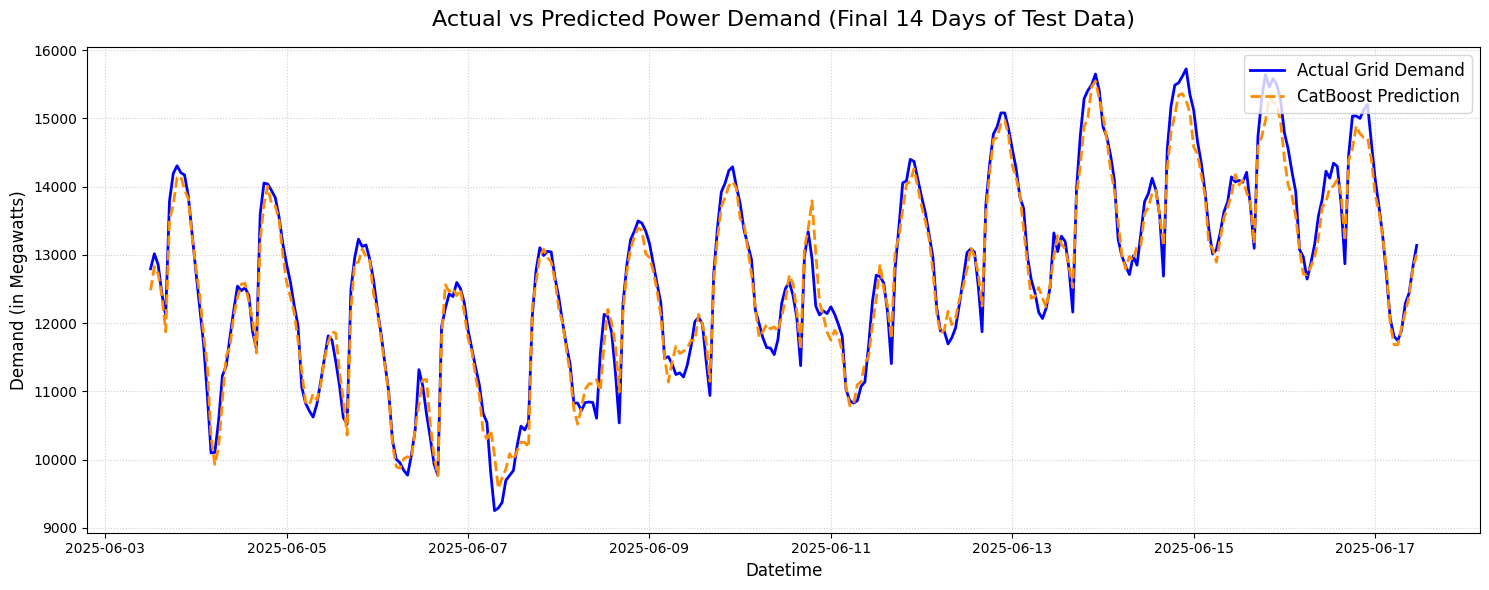

In [ ]:
window = 24 * 14
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[-window:], y_test.values[-window:], label='Actual Grid Demand', color='blue', linewidth=2)
plt.plot(y_test.index[-window:], cb_pred[-window:], label='CatBoost Prediction', color='darkorange', linestyle='--', linewidth=2)

plt.title("Actual vs Predicted Power Demand (Final 14 Days of Test Data)", fontsize=16, pad=15)
plt.ylabel("Demand (in Megawatts)", fontsize=12)
plt.xlabel("Datetime", fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()